# 04 — Economy Factors
Analyses pistol round impact and buy-type win rates by tier.
NOTE: series_economy covers ~73% T1 / ~81% T2 of working matches.


In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt

from eda.utils import load_tables, enrich_matches, get_working_matches, savefig

tables = load_tables()
matches = enrich_matches(tables['matches'])
working = get_working_matches(matches)


In [2]:
# Build: series_economy joined with winner_team_id, and impute missing team_ids
econ = tables['series_economy']
teams_df = tables['teams']

df = econ.merge(working[['match_id', 'tier', 'team1_id', 'team2_id', 'winner_team_id']], on='match_id', how='inner')
tag_map = teams_df.set_index('team_id')['veto_tag'].to_dict()
df['team1_tag'] = df['team1_id'].map(tag_map)
df['team2_tag'] = df['team2_id'].map(tag_map)

mask_null = df['team_id'].isna()
mask1 = mask_null & (df['team_tag'] == df['team1_tag'])
df.loc[mask1, 'team_id'] = df.loc[mask1, 'team1_id']
mask2 = mask_null & (df['team_tag'] == df['team2_tag'])
df.loc[mask2, 'team_id'] = df.loc[mask2, 'team2_id']

known = df[df['team_id'].notna()].groupby('match_id')['team_id'].apply(list).to_dict()

def fill_remaining(row):
    if pd.notna(row['team_id']):
        return row['team_id']
    m_id = row['match_id']
    if m_id in known:
        k_list = known[m_id]
        if len(k_list) == 1:
            k_id = k_list[0]
            if k_id == row['team1_id']:
                return row['team2_id']
            elif k_id == row['team2_id']:
                return row['team1_id']
    return row['team_id']

df['team_id'] = df.apply(fill_remaining, axis=1)

# Drop missing team IDs for win rate calculations
econ_w = df.dropna(subset=['team_id']).copy()
econ_w['match_won'] = (econ_w['team_id'] == econ_w['winner_team_id']).astype(int)

print(f"Economy rows after cleaning: {len(econ_w):,}")
print(econ_w['tier'].value_counts())


Economy rows after cleaning: 28,620
tier
tier2            13518
tier1            10682
game_changers     4420
Name: count, dtype: int64


Match win rate by pistols won and tier:
pistols_won           0         1         2
tier                                       
game_changers  0.302760  0.499080  0.695459
tier1          0.322675  0.496374  0.672179
tier2          0.337539  0.490831  0.645254


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/04_pistol_impact.png


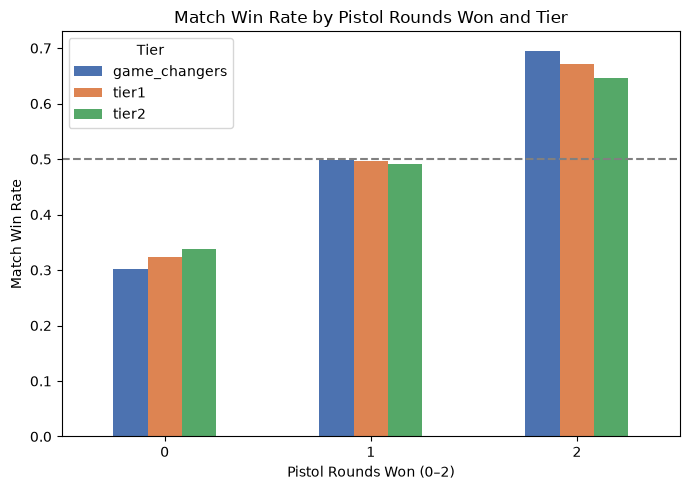

In [3]:
# 4a. Pistol impact: win rate by number of pistol rounds won
pistol_wr = econ_w.groupby(['tier','pistols_won'])['match_won'].mean().unstack()
print("Match win rate by pistols won and tier:")
print(pistol_wr.to_string())

fig, ax = plt.subplots(figsize=(7,5))
pistol_wr.T.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Match Win Rate by Pistol Rounds Won and Tier')
ax.set_xlabel('Pistol Rounds Won (0–2)')
ax.set_ylabel('Match Win Rate')
ax.axhline(0.5, color='gray', linestyle='--')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Tier')
plt.tight_layout()
savefig(fig, '04_pistol_impact')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/04_buy_type_winrate.png


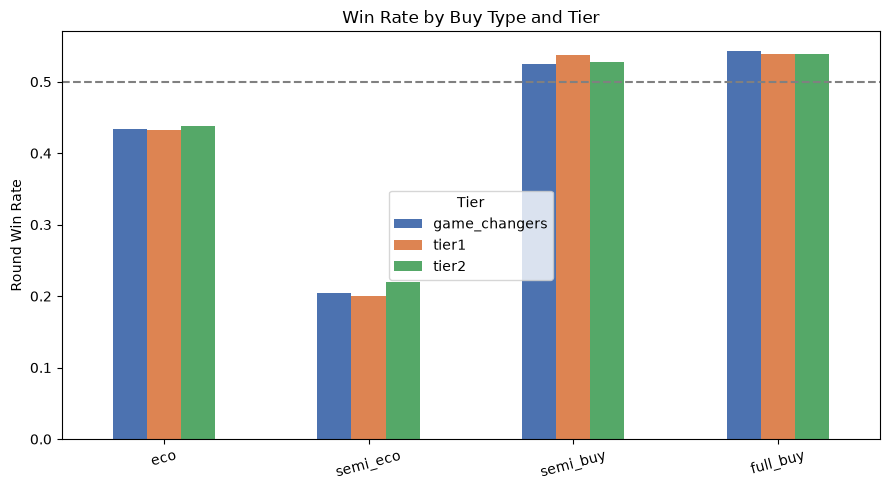

In [4]:
# 4b. Buy-type win rates
buy_types = ['eco','semi_eco','semi_buy','full_buy']
for bt in buy_types:
    econ_w[f'{bt}_winrate'] = (econ_w[f'{bt}_won'] / econ_w[f'{bt}_rounds'].replace(0, pd.NA))

bt_wr = econ_w.groupby('tier')[[f'{bt}_winrate' for bt in buy_types]].mean()
bt_wr.columns = buy_types

fig, ax = plt.subplots(figsize=(9,5))
bt_wr.T.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Win Rate by Buy Type and Tier')
ax.set_ylabel('Round Win Rate')
ax.axhline(0.5, color='gray', linestyle='--')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Tier')
plt.tight_layout()
savefig(fig, '04_buy_type_winrate')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/04_fullbuy_efficiency.png


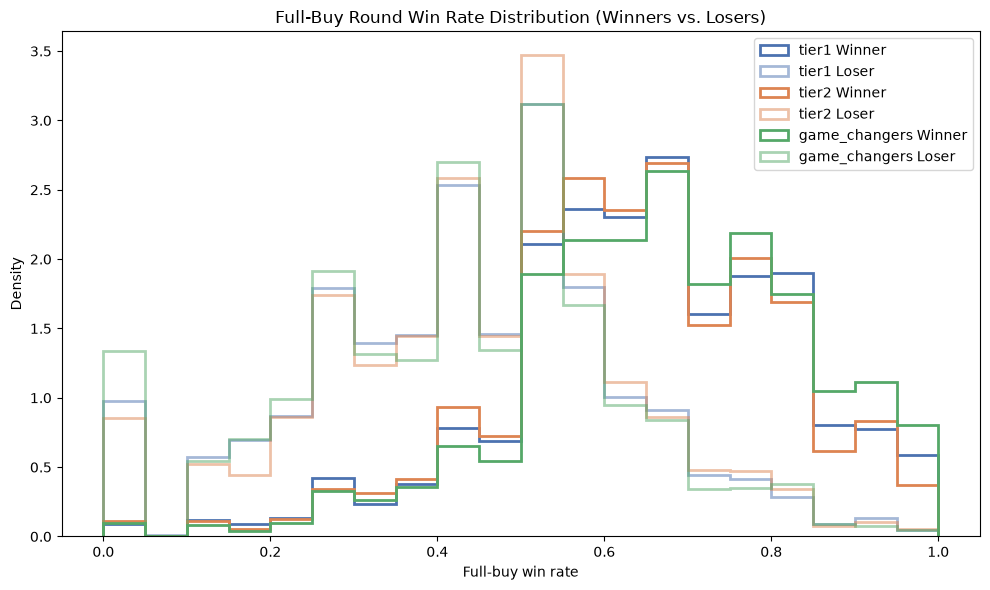

In [5]:
# 4c. Full-buy efficiency: winner vs. loser full_buy_winrate
fig, ax = plt.subplots(figsize=(10,6))
colors = {'tier1': '#4C72B0', 'tier2': '#DD8452', 'game_changers': '#55A868'}
for tier in ['tier1','tier2','game_changers']:
    for outcome, label, alpha in [(1,'Winner',1.0),(0,'Loser',0.5)]:
        data = (econ_w[(econ_w['tier']==tier) & (econ_w['match_won']==outcome)]
                ['full_buy_winrate'].dropna())
        ax.hist(data, bins=20, alpha=alpha, density=True, color=colors[tier],
                label=f'{tier} {label}', histtype='step', linewidth=2)
ax.set_title('Full-Buy Round Win Rate Distribution (Winners vs. Losers)')
ax.set_xlabel('Full-buy win rate')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
savefig(fig, '04_fullbuy_efficiency')
plt.show()
